In [4]:
!pip install beautifulsoup4

In [1]:
#import library for scrap data 
from bs4 import BeautifulSoup
import requests
import pandas as pd

In [2]:
url="https://www.citypopulation.de/en/egypt/cities/"
page=requests.get(url)
soup=BeautifulSoup(page.text,'html')

In [3]:
print(soup)

<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8"/>
<meta content="Arab Republic of Egypt with population statistics, maps, charts, weather and web information." name="description"/>
<title>Egypt: Governorates, Major Cities &amp; Towns - Population Statistics, Maps, Charts, Weather and Web Information</title>
<link href="/favicon.ico" rel="shortcut icon"/>
<script src="/js/cp_data_m.js"></script>
<script src="/js/cp_citypage_m.js"></script>
<script src="/js/cp_menu.js"></script>
<style>
    article.cpage { top: 469px }
    div#map { height: 369px }
    @media screen and (min-width: 1467px) {
      article.cpage { top: 99px; left: 740px }
      div#map { left: 160px; top: -1px; height: auto; bottom: -1px; width: 560px }
      header.cpage { left: 740px }
      div#headline { left: 722px }
    }
  </style>
</head>
<body itemscope="" itemtype="http://schema.org/Country" onload="start()">
<script>writeMenu('en','htmlpage','egypt-cities')</script>
<div class="mobiadv">
<script>s

In [4]:
#<article class="cpage swapped noviz9 noviz8" >
table=soup.find_all("table")[0]
print(table)

<table class="data" id="tl">
<colgroup><col data-width="0"/><col data-width="0"/><col data-width="662"/><col data-width="757"/><col data-width="578"/><col data-width="508"/><col data-width="438"/><col data-width="368"/><col data-width="298"/><col data-width="0"/><col style="visibility:collapse"/><col style="visibility:collapse"/></colgroup>
<thead>
<tr id="tlh"><th class="rname" data-coltype="name" onclick="javascript:sort('tl',0,false)" title="Sort"><a href="javascript:sort('tl',0,false)">Name</a></th><th class="rabbr" data-coltype="abbr" onclick="javascript:sort('tl',1,false)" title="Sort"><a href="javascript:sort('tl',1,false)">Abbr.</a></th><th class="rnative" data-coltype="othername" onclick="javascript:sort('tl',2,false)" title="Sort"><a href="javascript:sort('tl',2,false)">Native</a></th><th data-coltype="capital" onclick="javascript:sort('tl',3,false)" title="Sort"><a href="javascript:sort('tl',3,false)">Capital</a></th><th class="rarea" data-coltype="other" onclick="javascript

In [5]:
columns=table.find_all("th")

In [6]:
title=[i.text.strip() for i in columns]
   
print (title)

['Name', 'Abbr.', 'Native', 'Capital', 'AreaA (km²)', 'PopulationCensus (Cp)1986-11-17', 'PopulationCensus (Cf)1996-11-19', 'PopulationCensus (Cf)2006-11-11', 'PopulationCensus (Cf)2017-03-28', 'PopulationEstimate (E)2023-07-01', '', '', 'Egypt', 'EGY', 'مصر', 'Al-Qāhirah', '996,603', '48,205,049', '59,276,672', '72,798,031', '94,798,827', '105,174,090']


In [7]:
df=pd.DataFrame(columns=title)

In [8]:
df.drop(columns=["Egypt","EGY","مصر","Al-Qāhirah","996,603","48,205,049","59,276,672","72,798,031","94,798,827","105,174,090"
],inplace=True)

In [9]:

df

,Name,Abbr.,Native,Capital,AreaA (km²),PopulationCensus (Cp)1986-11-17,PopulationCensus (Cf)1996-11-19,PopulationCensus (Cf)2006-11-11,PopulationCensus (Cf)2017-03-28,PopulationEstimate (E)2023-07-01,,


In [10]:
columns_data=table.find_all("tr")

In [11]:
for row in columns_data[1:]:
    row_data=row.find_all("td")
    individual_row=[data.text.strip() for data in row_data]
    length=len(df)
    df.loc[length]=individual_row[-1]

In [12]:
df.to_csv(r'D:\data visu\enviroment.csv',index=False)

In [13]:
def wrangle(filepath1):
    
    #define my data set 
    df=pd.read_csv(filepath1)
    df.drop(df.columns[-1], axis=1, inplace = True)
    df=df.drop(columns=["PopulationCensus (Cp)1986-11-17","PopulationCensus (Cf)1996-11-19","PopulationCensus (Cf)2006-11-11","PopulationCensus (Cf)2017-03-28","Unnamed: 10"])
    #reset index
    df.reset_index(drop=True, inplace=True)
    #change columns name 
    new_columns = {
        'Name': 'Governorate',
        'Abbr.': 'Abbreviation',  
        'Native': 'Native Name',  
        'Capital': 'Capital City', 
        'AreaA (km²)': 'Area (km²)', 
        'PopulationEstimate (E)2023-07-01': 'Population Estimate (July 2023)' 
    }

    # Rename columns based on the new_columns dictionary
    df.rename(columns=new_columns, inplace=True)

    return df
    

In [14]:
df=wrangle("enviroment.csv")
df

,Governorate,Abbreviation,Native Name,Capital City,Area (km²),Population Estimate (July 2023)
0,Ad-Daqahiyah [Dakahlia],DQH,الدقهلية,Al-Manṣūrah,"3,538","7,050,004"
1,Al-Baḥr al-Aḥmar [Red Sea],BAH,البحر الأحمر,Al-Ghurdaqah,"120,000","403,077"
2,Al-Buḥayrah [Beheira],BHR,البحيرة,Damanhūr,"9,826","6,878,289"
3,Al-Fayyūm [Fayoum],FYM,الفيوم,Al-Fayyūm,"6,068","4,080,645"
4,Al-Gharbiyah [Gharbia],GHB,الغربية,Ṭanṭā,"1,942","5,439,085"
5,Al-Iskandariyah [Alexandria],ISK,الإسكندرية,Al-Iskandariyah,"2,300","5,546,663"
6,Al-Ismā'īliyah [Ismaïlia],ISM,الإسماعيلية,Al-Ismā'īliyah,"5,067","1,452,743"
7,Al-Jīzah [Giza],JIZ,الجيزة,Al-Jīzah,"13,184","9,514,540"
8,Al-Minūfiyah [Monufia],MNF,المنوفية,Shibīn al-Kawm,"2,499","4,736,945"
9,Al-Minyā,MNY,المنيا,Al-Minyā,"32,279","6,337,595"


In [4]:
governorates_data = {
    "Ad Daqahliyah": {
        'x': 258,
        'y': 46,
        'area_km2': 3538,
        'population': 7050004
    },
    "Al Bahr al Ahmar": {
        'x': 314,
        'y': 172,
        'area_km2': 120000,
        'population': 403077
    },
    "Al Buhayrah": {
        'x': 221,
        'y': 62,
        'area_km2': 9826,
        'population': 6878289
    },
    "Al Fayyum": {
        'x': 232,
        'y': 105,
        'area_km2': 6068,
        'population': 4080645
    },
    "Al Gharbiyah": {
        'x': 247,
        'y': 53,
        'area_km2': 1942,
        'population': 5439085
    },
    "Al Iskandariyah": {
        'x': 207,
        'y': 54,
        'area_km2': 2300,
        'population': 5546663
    },
    "Al Isma`iliyah": {
        'x': 290,
        'y': 63,
        'area_km2': 5067,
        'population': 1452743
    },
    "Al Jizah": {
        'x': 191,
        'y': 125,
        'area_km2': 13184,
        'population': 9514540
    },
    "Al Minufiyah": {
        'x': 244,
        'y': 65,
        'area_km2': 2499,
        'population': 4736945
    },
    "Al Minya": {
        'x': 227,
        'y': 144,
        'area_km2': 32279,
        'population': 6337595
    },
    "Al Qahirah": {
        'x': 264,
        'y': 102,
        'area_km2': 3085,  
        'population': 10248385  
    },
    "Al Qalyubiyah": {
        'x': 252,
        'y': 72,
        'area_km2': 1124,  
        'population': 6137688 
    },
    "Al Uqsur": {
        'x': 296,
        'y': 230,
        'area_km2': 2960, 
        'population': 1400640 
    },
    "Al Wadi al Jadid": {
        'x': 152,
        'y': 218,
        'area_km2': 440098,  
        'population': 266926  
    },
    "As Suways": {
        'x': 282,
        'y': 90,
        'area_km2': 9002,  
        'population': 792551  
    },
    "Ash Sharqiyah": {
        'x': 264,
        'y': 60,
        'area_km2':4911,  
        'population': 7909342  
    },
    "Aswan": {
        'x': 306,
        'y': 254,
        'area_km2': 62726,  
        'population': 1656218  
    },
    "Asyut": {
        'x': 262,
        'y': 171,
        'area_km2': 13720,  
        'population': 5061934  
    },
    "Bani Suwayf": {
        'x': 250,
        'y': 119,
        'area_km2': 10954,  
        'population':3592039  
    },
    "Bur Sa`id": {
        'x': 287,
        'y': 45,
        'area_km2': 1345,  
        'population': 791749  
    },
    "Dumyat": {
        'x': 268,
        'y': 34,
        'area_km2': 910, 
        'population': 1618239 
    },
    "Janub Sina'": {
        'x': 329,
        'y': 117,
        'area_km2': 31272,  
        'population': 116479  
    },
    "Kafr ash Shaykh": {
        'x': 242,
        'y': 38,
        'area_km2': 166563,  
        'population': 547702  
    },
    "Matrouh": {
        'x': 122,
        'y': 72,
        'area_km2': 3467,  
        'population': 3718316 
    },
    "Qina": {
        'x': 308,
        'y': 217,
        'area_km2': 8980,  
        'population': 3640916  
    },
    "Shamal Sina'": {
        'x': 326,
        'y': 68,
        'area_km2': 27564,  
        'population': 508109  
    },
    "Suhaj": {
        'x': 278,
        'y': 196,
        'area_km2': 11218, 
        'population': 5727271  
    }
}

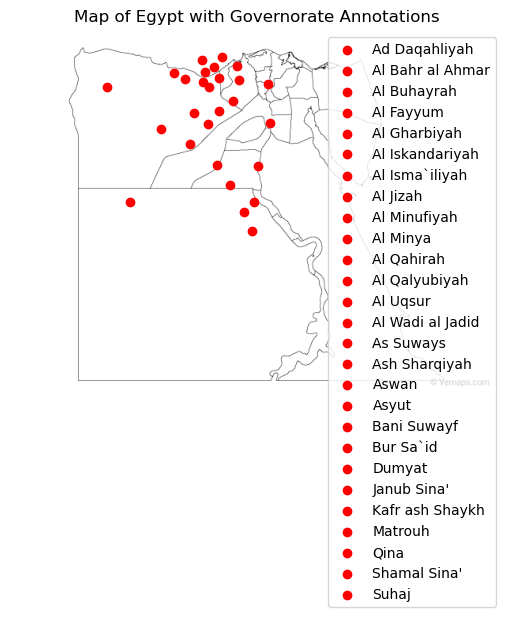

In [7]:
import matplotlib.pyplot as plt
from PIL import Image

# Load the map image of Egypt
map_image = Image.open('eg-02.png')

# Display the map image
plt.imshow(map_image)
plt.title('Map of Egypt with Governorate Annotations')

# Plot each governorate's coordinate on the map
for governorate, data in governorates_data.items():
    plt.scatter(data['x'], data['y'], color='red', marker='o', label=governorate)

# Add legend and customize plot
plt.axis('off')  # Turn off axis
plt.legend(loc='upper right')
plt.show()
